# 04 — Pipeline C: Deep Learning Models (RNN / LSTM / BiLSTM)
### BI-RADS Classification from Mammography Reports

This notebook implements **Pipeline C** of the master workflow:

```
Text Tokenization → Embedding Layer → [RNN | LSTM | BiLSTM] → Predictions
```

**Inputs (already preprocessed, from Phase 2):**
- `train.csv`
- `validation.csv`
- `test.csv`

**Outputs (Phase 4 deliverables):**
- `dl_predictions.csv`
- `dl_metrics.json`
- Confusion matrices & training curves (saved to `results/figures/`)
- Trained model weights (`.h5` / `.keras`)

> Adjust the `CONFIG` block in the next cell — file paths and column names — to match your actual dataset before running.

## 1. Setup & Imports

In [ ]:
# If running on a fresh Colab runtime, uncomment to ensure versions are compatible
# !pip install -q tensorflow scikit-learn seaborn

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Bidirectional,
    Dense, Dropout, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [ ]:
# (Optional) Mount Google Drive — skip if already mounted
from google.colab import drive
drive.mount('/content/mydrive')

Drive already mounted at /content/mydrive; to attempt to forcibly remount, call drive.mount("/content/mydrive", force_remount=True).


## 2. Configuration

Set paths, column names, and hyperparameters here. This is the only section you should need to edit.

In [ ]:
CONFIG = {
    # ---- Paths (already preprocessed splits from Phase 2) ----
    "train_path": "/content/mydrive/MyDrive/NLP_Research_Project/data/splits/train.csv",
    "val_path":   "/content/mydrive/MyDrive/NLP_Research_Project/data/splits/validation.csv",
    "test_path":  "/content/mydrive/MyDrive/NLP_Research_Project/data/splits/test.csv",

    # ---- Output paths ----
    "output_dir":     "/content/mydrive/MyDrive/NLP_Research_Project/results",
    "predictions_csv": "dl_predictions.csv",
    "metrics_json":     "dl_metrics.json",
    "model_dir":        "/content/mydrive/MyDrive/NLP_Research_Project/models/deep_learning",

    # ---- Column names: EDIT to match your processed_dataset.csv schema ----
    "text_col":  "text",   # column containing the cleaned report text
    "label_col": "label",    # column containing the BI-RADS class label

    # ---- Tokenization / sequence hyperparameters ----
    "vocab_size": 20000,
    "max_len": 300,          # max tokens per report (pad/truncate to this length)
    "oov_token": "<OOV>",

    # ---- Embedding / model hyperparameters ----
    "embedding_dim": 128,
    "rnn_units": 128,
    "dropout_rate": 0.4,
    "batch_size": 32,
    "epochs": 30,
    "learning_rate": 1e-3,
    "patience": 4,            # EarlyStopping patience
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
os.makedirs(os.path.join(CONFIG["output_dir"], "figures"), exist_ok=True)
os.makedirs(os.path.join(CONFIG["output_dir"], "confusion_matrices"), exist_ok=True)
os.makedirs(CONFIG["model_dir"], exist_ok=True)
print("Config ready.")

Config ready.


## 3. Load Preprocessed Splits

In [ ]:
train_df = pd.read_csv(CONFIG["train_path"])
val_df   = pd.read_csv(CONFIG["val_path"])
test_df  = pd.read_csv(CONFIG["test_path"])

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

train_df.head()

Train shape: (6425, 4)
Val shape:   (1377, 4)
Test shape:  (1377, 4)


,id,raw_text,text,label
0,Acc13491,Clinical indication:\n\n tracking.\n\nFamily h...,clinical indication tracking. family history o...,2
1,Acc6472,Clinical indication:\n\n tracking.\n\nFindings...,clinical indication tracking. findings partial...,2
2,Acc13195,Clinical indication:\n\n tracking.\n\nFindings...,clinical indication tracking. findings predomi...,2
3,Acc2281,Clinical indication:\n\n tracking.\n\nFindings...,clinical indication tracking. findings ventric...,2
4,Acc18618,Clinical indication:\n\n tracking.\n\nFindings...,clinical indication tracking. findings heterog...,2


In [ ]:
# Sanity checks — confirm the expected columns exist
for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    missing = [c for c in [CONFIG["text_col"], CONFIG["label_col"]] if c not in df.columns]
    if missing:
        raise ValueError(
            f"{name} split is missing column(s) {missing}. "
            f"Available columns: {list(df.columns)}. "
            f"Update CONFIG['text_col'] / CONFIG['label_col'] accordingly."
        )

# Drop rows with missing text or label, just in case
train_df = train_df.dropna(subset=[CONFIG["text_col"], CONFIG["label_col"]]).reset_index(drop=True)
val_df   = val_df.dropna(subset=[CONFIG["text_col"], CONFIG["label_col"]]).reset_index(drop=True)
test_df  = test_df.dropna(subset=[CONFIG["text_col"], CONFIG["label_col"]]).reset_index(drop=True)

print("Class distribution (train):")
print(train_df[CONFIG["label_col"]].value_counts())

Class distribution (train):
label
2    5126
3     498
0     423
1     176
4     150
6      32
5      20
Name: count, dtype: int64


## 4. Label Encoding

In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(train_df[CONFIG["label_col"]])

y_train = label_encoder.transform(train_df[CONFIG["label_col"]])
y_val   = label_encoder.transform(val_df[CONFIG["label_col"]])
y_test  = label_encoder.transform(test_df[CONFIG["label_col"]])

num_classes = len(label_encoder.classes_)
print("Classes:", list(label_encoder.classes_))
print("Number of classes:", num_classes)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat   = to_categorical(y_val, num_classes=num_classes)
y_test_cat  = to_categorical(y_test, num_classes=num_classes)

Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Number of classes: 7


## 5. Text Tokenization

Fitted vocabulary size (word_index): 2256
Vocabulary size used by model: 2257
X_train shape: (6425, 300)
X_val shape:   (1377, 300)
X_test shape:  (1377, 300)


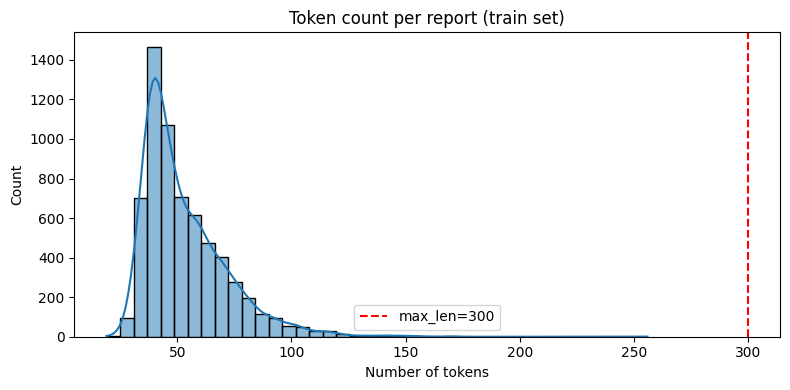

In [ ]:
tokenizer = Tokenizer(
    num_words=CONFIG["vocab_size"],
    oov_token=CONFIG["oov_token"]
)
tokenizer.fit_on_texts(train_df[CONFIG["text_col"]])

vocab_actual_size = min(CONFIG["vocab_size"], len(tokenizer.word_index) + 1)
print("Fitted vocabulary size (word_index):", len(tokenizer.word_index))
print("Vocabulary size used by model:", vocab_actual_size)

def texts_to_padded(df, col):
    seqs = tokenizer.texts_to_sequences(df[col])
    return pad_sequences(seqs, maxlen=CONFIG["max_len"], padding="post", truncating="post")

X_train = texts_to_padded(train_df, CONFIG["text_col"])
X_val   = texts_to_padded(val_df,   CONFIG["text_col"])
X_test  = texts_to_padded(test_df,  CONFIG["text_col"])

print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

# Quick look at sequence length distribution to sanity-check MAX_LEN
lengths = [len(s) for s in tokenizer.texts_to_sequences(train_df[CONFIG["text_col"]])]
plt.figure(figsize=(8, 4))
sns.histplot(lengths, bins=40, kde=True)
plt.axvline(CONFIG["max_len"], color="red", linestyle="--", label=f'max_len={CONFIG["max_len"]}')
plt.title("Token count per report (train set)")
plt.xlabel("Number of tokens")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "figures", "dl_sequence_length_distribution.png"), dpi=150)
plt.show()

## 6. Model Architectures

Three variants sharing the same Embedding layer configuration, differing only in the recurrent block:

- **RNN** — `SimpleRNN` baseline
- **LSTM** — standard unidirectional LSTM
- **BiLSTM** — Bidirectional LSTM (reads the report forwards and backwards)

In [ ]:
def build_model(architecture: str, vocab_size: int, embedding_dim: int,
                 max_len: int, rnn_units: int, num_classes: int,
                 dropout_rate: float, learning_rate: float) -> tf.keras.Model:
    """
    Builds one of: 'rnn', 'lstm', 'bilstm'
    Shared structure: Embedding -> Recurrent block -> Pooling -> Dense -> Softmax
    """
    model = Sequential(name=f"{architecture}_birads_classifier")
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len,
        mask_zero=True,
        name="embedding"
    ))

    if architecture == "rnn":
        model.add(SimpleRNN(rnn_units, return_sequences=True))
    elif architecture == "lstm":
        model.add(LSTM(rnn_units, return_sequences=True))
    elif architecture == "bilstm":
        model.add(Bidirectional(LSTM(rnn_units, return_sequences=True)))
    else:
        raise ValueError(f"Unknown architecture: {architecture}")

    model.add(GlobalMaxPooling1D())
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Quick architecture preview
build_model("bilstm", vocab_actual_size, CONFIG["embedding_dim"], CONFIG["max_len"],
            CONFIG["rnn_units"], num_classes, CONFIG["dropout_rate"], CONFIG["learning_rate"]).summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "bilstm_birads_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Train All Three Models

In [ ]:
architectures = ["rnn", "lstm", "bilstm"]
trained_models = {}
histories = {}

for arch in architectures:
    print(f"\n{'='*60}\nTraining: {arch.upper()}\n{'='*60}")

    model = build_model(
        architecture=arch,
        vocab_size=vocab_actual_size,
        embedding_dim=CONFIG["embedding_dim"],
        max_len=CONFIG["max_len"],
        rnn_units=CONFIG["rnn_units"],
        num_classes=num_classes,
        dropout_rate=CONFIG["dropout_rate"],
        learning_rate=CONFIG["learning_rate"],
    )

    checkpoint_path = os.path.join(CONFIG["model_dir"], f"{arch}_best.keras")
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=CONFIG["patience"],
                       restore_best_weights=True, verbose=1),
        ModelCheckpoint(checkpoint_path, monitor="val_loss",
                         save_best_only=True, verbose=0),
    ]

    history = model.fit(
        X_train, y_train_cat,
        validation_data=(X_val, y_val_cat),
        batch_size=CONFIG["batch_size"],
        epochs=CONFIG["epochs"],
        callbacks=callbacks,
        verbose=1
    )

    trained_models[arch] = model
    histories[arch] = history.history

print("\nAll models trained.")


Training: RNN
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d_1' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


201/201 ━━━━━━━━━━━━━━━━━━━━ 48s 222ms/step - accuracy: 0.7888 - loss: 0.8014 - val_accuracy: 0.7974 - val_loss: 0.5634
Epoch 2/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 83s 228ms/step - accuracy: 0.8047 - loss: 0.5879 - val_accuracy: 0.8279 - val_loss: 0.4681
Epoch 3/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 47s 235ms/step - accuracy: 0.8247 - loss: 0.4946 - val_accuracy: 0.8715 - val_loss: 0.4127
Epoch 4/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 47s 234ms/step - accuracy: 0.8532 - loss: 0.4223 - val_accuracy: 0.8598 - val_loss: 0.3871
Epoch 5/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 45s 223ms/step - accuracy: 0.8685 - loss: 0.3822 - val_accuracy: 0.8613 - val_loss: 0.3649
Epoch 6/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 42s 207ms/step - accuracy: 0.8789 - loss: 0.3495 - val_accuracy: 0.8642 - val_loss: 0.3675
Epoch 7/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 84s 216ms/step - accuracy: 0.8873 - loss: 0.3326 - val_accuracy: 0.8686 - val_loss: 0.3603
Epoch 8/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 44s 217ms/step - accuracy: 0.8890 - loss: 0.3139 - val

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d_2' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


201/201 ━━━━━━━━━━━━━━━━━━━━ 150s 730ms/step - accuracy: 0.7883 - loss: 0.8565 - val_accuracy: 0.8032 - val_loss: 0.5752
Epoch 2/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 145s 717ms/step - accuracy: 0.8139 - loss: 0.5469 - val_accuracy: 0.8272 - val_loss: 0.4459
Epoch 3/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 144s 716ms/step - accuracy: 0.8551 - loss: 0.4216 - val_accuracy: 0.8744 - val_loss: 0.3653
Epoch 4/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 143s 715ms/step - accuracy: 0.8702 - loss: 0.3705 - val_accuracy: 0.8816 - val_loss: 0.3425
Epoch 5/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 203s 718ms/step - accuracy: 0.8845 - loss: 0.3276 - val_accuracy: 0.8736 - val_loss: 0.3449
Epoch 6/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 140s 699ms/step - accuracy: 0.8990 - loss: 0.2968 - val_accuracy: 0.8896 - val_loss: 0.3463
Epoch 7/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 139s 690ms/step - accuracy: 0.9085 - loss: 0.2728 - val_accuracy: 0.8932 - val_loss: 0.3180
Epoch 8/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 143s 710ms/step - accuracy: 0.9128 - loss: 0.26

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d_3' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


201/201 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.7913 - loss: 0.7658 - val_accuracy: 0.8381 - val_loss: 0.4887
Epoch 2/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 321s 1s/step - accuracy: 0.8302 - loss: 0.4895 - val_accuracy: 0.8497 - val_loss: 0.4035
Epoch 3/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.8581 - loss: 0.4023 - val_accuracy: 0.8802 - val_loss: 0.3503
Epoch 4/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.8791 - loss: 0.3446 - val_accuracy: 0.8707 - val_loss: 0.3562
Epoch 5/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.8911 - loss: 0.3126 - val_accuracy: 0.8816 - val_loss: 0.3396
Epoch 6/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step - accuracy: 0.8971 - loss: 0.2895 - val_accuracy: 0.8940 - val_loss: 0.3415
Epoch 7/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.9077 - loss: 0.2633 - val_accuracy: 0.9005 - val_loss: 0.3069
Epoch 8/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - accuracy: 0.9156 - loss: 0.2393 - val_accuracy: 0.898

## 8. Training Curves

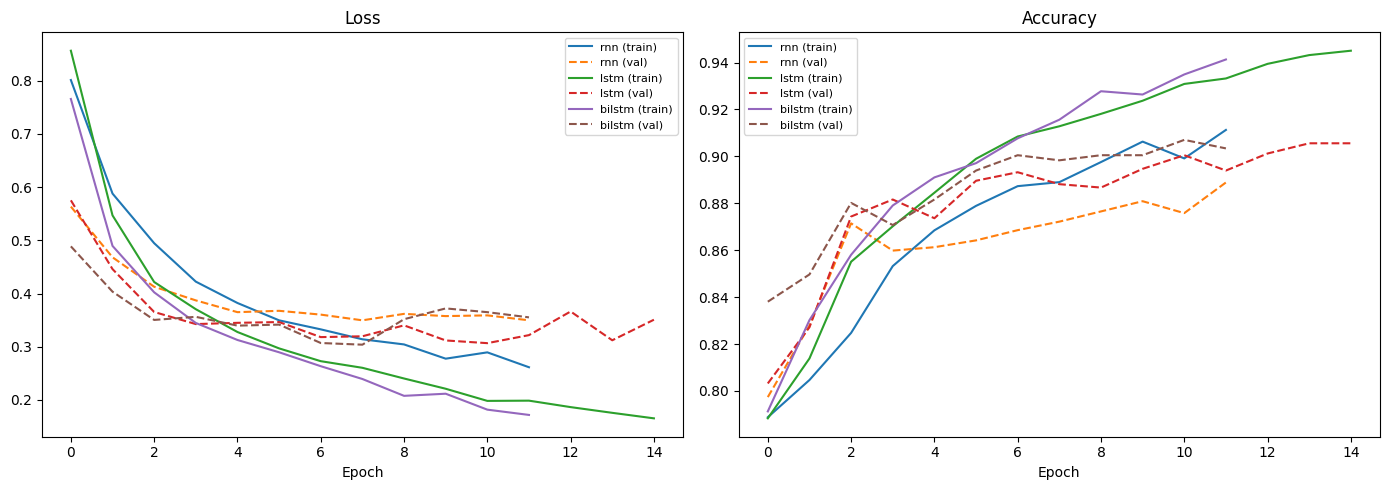

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for arch in architectures:
    axes[0].plot(histories[arch]["loss"], label=f"{arch} (train)")
    axes[0].plot(histories[arch]["val_loss"], linestyle="--", label=f"{arch} (val)")
    axes[1].plot(histories[arch]["accuracy"], label=f"{arch} (train)")
    axes[1].plot(histories[arch]["val_accuracy"], linestyle="--", label=f"{arch} (val)")

axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=8)

axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "figures", "dl_training_curves.png"), dpi=150)
plt.show()

## 9. Evaluation on Test Set

In [ ]:
def evaluate_model(model, X_test, y_test_labels, label_encoder, arch_name):
    probs = model.predict(X_test, verbose=0)
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test_labels, preds)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        y_test_labels, preds, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_test_labels, preds, average="weighted", zero_division=0
    )

    report = classification_report(
        y_test_labels, preds,
        target_names=[str(c) for c in label_encoder.classes_],
        output_dict=True, zero_division=0
    )

    metrics = {
        "architecture": arch_name,
        "accuracy": float(acc),
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1_macro),
        "f1_weighted": float(f1_weighted),
        "per_class_report": report,
    }
    return preds, probs, metrics

all_metrics = {}
all_preds = {}

for arch in architectures:
    preds, probs, metrics = evaluate_model(
        trained_models[arch], X_test, y_test, label_encoder, arch
    )
    all_metrics[arch] = metrics
    all_preds[arch] = preds
    print(f"\n{arch.upper()} — Accuracy: {metrics['accuracy']:.4f} | "
          f"Macro F1: {metrics['f1_macro']:.4f} | Weighted F1: {metrics['f1_weighted']:.4f}")


RNN — Accuracy: 0.8722 | Macro F1: 0.4114 | Weighted F1: 0.8608


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d_2' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(



LSTM — Accuracy: 0.9027 | Macro F1: 0.5309 | Weighted F1: 0.8988


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d_3' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(



BILSTM — Accuracy: 0.8983 | Macro F1: 0.5344 | Weighted F1: 0.8962


## 10. Confusion Matrices

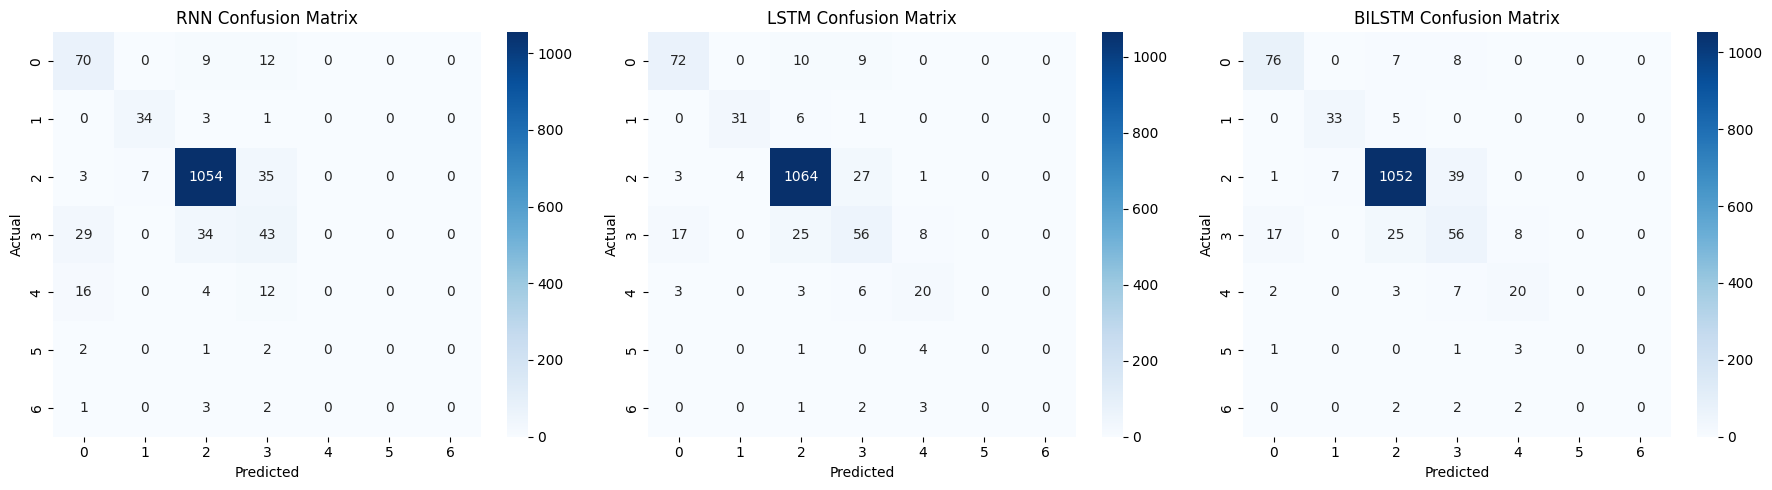

In [ ]:
fig, axes = plt.subplots(1, len(architectures), figsize=(6 * len(architectures), 5))
if len(architectures) == 1:
    axes = [axes]

class_names = [str(c) for c in label_encoder.classes_]

for ax, arch in zip(axes, architectures):
    cm = confusion_matrix(y_test, all_preds[arch])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{arch.upper()} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "confusion_matrices", "dl_confusion_matrices.png"), dpi=150)
plt.show()

## 11. Model Comparison Table

In [ ]:
comparison_df = pd.DataFrame([
    {
        "Model": arch.upper(),
        "Accuracy": all_metrics[arch]["accuracy"],
        "Precision (macro)": all_metrics[arch]["precision_macro"],
        "Recall (macro)": all_metrics[arch]["recall_macro"],
        "F1 (macro)": all_metrics[arch]["f1_macro"],
        "F1 (weighted)": all_metrics[arch]["f1_weighted"],
    }
    for arch in architectures
]).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
0,BILSTM,0.898330,0.524536,0.544875,0.534412,0.896172
1,LSTM,0.902687,0.530311,0.532636,0.530877,0.898768
2,RNN,0.872186,0.394416,0.432669,0.411434,0.860787


## 12. Save Predictions & Metrics (Deliverables for Phase 4)

In [ ]:
# ---- dl_predictions.csv ----
pred_records = []
for arch in architectures:
    decoded_preds = label_encoder.inverse_transform(all_preds[arch])
    for i in range(len(decoded_preds)):
        pred_records.append({
            "report_id": test_df.index[i] if "report_id" not in test_df.columns else test_df.iloc[i]["report_id"],
            "model": arch,
            "true_label": test_df.iloc[i][CONFIG["label_col"]],
            "predicted_label": decoded_preds[i],
        })

dl_predictions_df = pd.DataFrame(pred_records)
pred_path = os.path.join(CONFIG["output_dir"], CONFIG["predictions_csv"])
dl_predictions_df.to_csv(pred_path, index=False)
print("Saved predictions to:", pred_path)

# ---- dl_metrics.json ----
metrics_path = os.path.join(CONFIG["output_dir"], CONFIG["metrics_json"])
with open(metrics_path, "w") as f:
    json.dump(all_metrics, f, indent=2)
print("Saved metrics to:", metrics_path)

# ---- comparison table as CSV too ----
comparison_path = os.path.join(CONFIG["output_dir"], "dl_comparison_table.csv")
comparison_df.to_csv(comparison_path, index=False)
print("Saved comparison table to:", comparison_path)

Saved predictions to: /content/mydrive/MyDrive/NLP_Research_Project/results/dl_predictions.csv
Saved metrics to: /content/mydrive/MyDrive/NLP_Research_Project/results/dl_metrics.json
Saved comparison table to: /content/mydrive/MyDrive/NLP_Research_Project/results/dl_comparison_table.csv


## 13. Notes for Integration with the Unified Evaluation (Phase 4)

- `dl_predictions.csv` uses the same schema convention (`report_id`, `model`, `true_label`, `predicted_label`) expected when merging with `ngram_predictions.csv` and `ml_predictions.csv` for the final comparative analysis.
- Model checkpoints (best weights per architecture) are saved under `CONFIG["model_dir"]` — reload with `tf.keras.models.load_model(path)`.
- If class imbalance is severe (common with BI-RADS categories), consider adding `class_weight` to `model.fit(...)` — computed with `sklearn.utils.class_weight.compute_class_weight`.
- To try pretrained embeddings (e.g. clinical word2vec/GloVe) instead of a trainable embedding layer, replace the `Embedding` layer construction in `build_model` with one initialized from a pretrained embedding matrix and set `trainable=False` (or `True` for fine-tuning).
- Runtime per architecture (wall-clock) can be captured by timing the `model.fit()` calls in Section 7 and added to `all_metrics` for the "Computational Cost" comparison in Phase 5.